# Advertising Dataset – Sales Prediction using Multiple Linear Regression

## Project Objective

A consumer goods company uses **TV, Radio, and Newspaper** advertising to promote its products.

The objective of this project is to:

1. Load and understand the Advertising dataset.
2. Use **TV, Radio, and Newspaper** as input features.
3. Use **Sales** as the target variable.
4. Build a **Multiple Linear Regression** model.
5. Train the model using historical data.
6. Predict sales for unseen test data.
7. Predict sales for a new advertising budget:
   - TV = 150
   - Radio = 20
   - Newspaper = 30
8. Evaluate prediction error using MAE, MSE, RMSE, and R².
9. Interpret the model coefficients.
10. Identify the advertising medium with the strongest and weakest impact.
11. Visualize actual sales versus predicted sales.
12. Provide a business recommendation and a technical improvement.

### Machine Learning Type

This is a **Supervised Learning** problem because the dataset contains the known target variable, `Sales`.

### Algorithm

We use **Multiple Linear Regression** because there are three input features.

The model learns:

**Sales = Intercept + (TV × TV coefficient) + (Radio × Radio coefficient) + (Newspaper × Newspaper coefficient)**


## Step 1 – Import the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Explanation
We import the libraries required for the project.

- **Pandas** is used to load and analyze the dataset.
- **NumPy** is used for numerical calculations.
- **Matplotlib** is used for visualization.
- `train_test_split` divides the data into training and testing sets.
- `LinearRegression` provides the Multiple Linear Regression algorithm.
- The evaluation metrics measure how accurately the model predicts sales.

## Step 2 – Load the Dataset

In [2]:
# Make sure Advertising.csv is in the same folder as this notebook.
df = pd.read_csv("Advertising.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### Explanation
`pd.read_csv()` reads the CSV file and stores it in a Pandas DataFrame called `df`.

The dataset should be named **Advertising.csv** and placed in the same folder as the notebook.

If your file has a different name or location, change the filename in `pd.read_csv()`.

At this stage, we have loaded the historical advertising and sales data.

## Step 3 – Display the First Few Records

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Explanation
`head()` displays the first five rows of the dataset.

This helps us verify that the data has loaded correctly and allows us to understand what the records look like.

We should see columns such as:

- TV
- Radio
- Newspaper
- Sales

## Step 4 – Examine the Available Columns

In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


### Explanation
This displays all the columns available in the dataset.

For this project, the important columns are:

- **TV** – advertising expenditure on television.
- **Radio** – advertising expenditure on radio.
- **Newspaper** – advertising expenditure on newspapers.
- **Sales** – product sales.

The first three are input features, while Sales is the target.

## Step 5 – Check the Dataset Shape

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Shape:", df.shape)

Number of rows: 200
Number of columns: 5
Shape: (200, 5)


### Explanation
`df.shape` returns the number of rows and columns.

The commonly used Advertising dataset contains **200 rows and 4 columns**.

Knowing the dataset size helps us understand how much historical data is available for training and testing.

## Step 6 – Understand the Data Types and Structure

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


### Explanation
`info()` gives information about:

- Column names
- Number of non-null values
- Data types
- Overall structure of the DataFrame

This is useful before machine learning because we need to make sure our input variables are in suitable numerical formats.

## Step 7 – Check for Missing Values

In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


### Explanation
`isnull().sum()` counts missing values in every column.

Missing values can cause problems during model training.

If every column shows `0`, there are no missing values and we can continue without performing missing-value treatment.

## Step 8 – Generate Descriptive Statistics

In [8]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


### Explanation
`describe()` provides statistical information such as:

- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

This helps us understand the distribution and range of advertising spending and sales.

## Step 9 – Define the Input Features and Target Variable

In [9]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Input features:")
print(X.head())

print("\nTarget variable:")
print(y.head())

Input features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target variable:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


### Explanation
We separate the dataset into **inputs (X)** and **output (y)**.

`X` contains the three advertising channels:

- TV
- Radio
- Newspaper

`y` contains:

- Sales

The model will learn how the three advertising variables are related to Sales.

## Step 10 – Split the Data into Training and Testing Sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature records:", X_train.shape[0])
print("Testing feature records:", X_test.shape[0])
print("Training target records:", y_train.shape[0])
print("Testing target records:", y_test.shape[0])

Training feature records: 160
Testing feature records: 40
Training target records: 160
Testing target records: 40


### Explanation
We divide the dataset into two parts:

- **80% training data** – used to teach the model.
- **20% testing data** – used to evaluate the model on unseen data.

`random_state=42` makes the split reproducible, meaning we get the same split whenever we run the notebook.

The test data is kept separate so that we can evaluate whether the model generalizes to new observations.

## Step 11 – Create the Multiple Linear Regression Model

In [11]:
model = LinearRegression()

print("Multiple Linear Regression model created.")

Multiple Linear Regression model created.


### Explanation
Here we create an instance of the `LinearRegression` algorithm.

Because we have three independent variables, this is called **Multiple Linear Regression**.

The model will learn the equation:

**Sales = β₀ + β₁(TV) + β₂(Radio) + β₃(Newspaper)**

where the β values are learned from the training data.

## Step 12 – Train the Model

In [12]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


### Explanation
`fit()` trains the model.

The model looks at the training values of:

- TV advertising
- Radio advertising
- Newspaper advertising

and their corresponding Sales values.

It then learns the best-fitting coefficients that describe the relationship between advertising expenditure and sales.

## Step 13 – Display the Intercept and Coefficients

In [13]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.6f}")

Intercept: 2.9790673381226274

Coefficients:
TV: 0.044730
Radio: 0.189195
Newspaper: 0.002761


### Explanation
The **intercept** represents the model's predicted Sales when all three advertising expenditures are zero.

The **coefficients** describe how predicted Sales changes when one advertising feature increases by one unit while the other features are kept constant.

For example, if the Radio coefficient is positive, increasing Radio advertising is associated with an increase in predicted Sales, holding TV and Newspaper spending constant.

The exact coefficient values are calculated from your dataset.

## Step 14 – Interpret the Advertising Coefficients

In [14]:
coefficients = pd.Series(model.coef_, index=X.columns)

print("Coefficient interpretation:")
for feature, coefficient in coefficients.items():
    if coefficient > 0:
        print(
            f"{feature}: {coefficient:.6f} -> positive estimated impact on Sales"
        )
    elif coefficient < 0:
        print(
            f"{feature}: {coefficient:.6f} -> negative estimated impact on Sales"
        )
    else:
        print(
            f"{feature}: {coefficient:.6f} -> approximately no estimated impact"
        )

Coefficient interpretation:
TV: 0.044730 -> positive estimated impact on Sales
Radio: 0.189195 -> positive estimated impact on Sales
Newspaper: 0.002761 -> positive estimated impact on Sales


### Explanation
A positive coefficient means that the feature has a positive estimated relationship with Sales, after accounting for the other advertising channels.

A negative coefficient means that the model estimates a negative relationship after accounting for the other features.


## Step 15 – Identify the Strongest and Weakest Advertising Medium

In [15]:
strongest_medium = coefficients.idxmax()
weakest_medium = coefficients.abs().idxmin()

print("Strongest positive coefficient:", strongest_medium)
print("Weakest coefficient by absolute magnitude:", weakest_medium)

print("\nAll coefficients:")
print(coefficients.sort_values(ascending=False))

Strongest positive coefficient: Radio
Weakest coefficient by absolute magnitude: Newspaper

All coefficients:
Radio        0.189195
TV           0.044730
Newspaper    0.002761
dtype: float64


### Explanation
`idxmax()` identifies the feature with the largest positive coefficient.

For this commonly used Advertising dataset, **Radio typically has the largest positive coefficient**, meaning it has the strongest estimated positive impact in the multiple regression model.

`abs().idxmin()` identifies the coefficient closest to zero, which is useful for identifying the weakest estimated relationship.

For this dataset, **Newspaper is typically the weakest**.

We should say **"estimated impact according to the model"** rather than claiming that one channel definitely causes sales.

## Step 16 – Predict Sales for the Test Data

In [16]:
y_pred = model.predict(X_test)

print("First 10 actual sales:")
print(y_test.head(10).values)

print("\nFirst 10 predicted sales:")
print(y_pred[:10])

First 10 actual sales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9]

First 10 predicted sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


### Explanation
The trained model is now used to predict Sales for `X_test`.

These observations were not used during model training.

Therefore, comparing `y_test` with `y_pred` tells us how well the model performs on unseen data.

## Step 17 – Create an Actual vs Predicted Table

In [17]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


### Explanation
This creates a table containing:

- Actual Sales from the dataset.
- Predicted Sales generated by the model.

If the predicted values are close to the actual values, the model is making good predictions.

## Step 18 – Calculate Mean Absolute Error (MAE)

In [18]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.4607567168117606


### Explanation
MAE measures the average absolute difference between actual and predicted Sales.

For example, if MAE is approximately 1.2, the model's predictions are off by about **1.2 sales units on average**.

For MAE:

**Lower is better.**

## Step 19 – Calculate Mean Squared Error (MSE)

In [19]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 3.1740973539761055


### Explanation
MSE calculates the average of the squared prediction errors.

Because errors are squared, larger errors have a greater effect on the MSE.

For MSE:

**Lower is better.**

## Step 20 – Calculate Root Mean Squared Error (RMSE)

In [20]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1.7815996615334506


### Explanation
RMSE is the square root of MSE.

It is useful because it is expressed in the same units as Sales.

For example, an RMSE of 1.5 means the typical prediction error is around 1.5 sales units, although RMSE is not simply an average error.

For RMSE:

**Lower is better.**

## Step 21 – Calculate R² Score

In [21]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.899438024100912


### Explanation
R², or the coefficient of determination, measures how much of the variation in Sales is explained by the model.

For example, an R² of 0.90 means the model explains approximately 90% of the variation in Sales for the evaluated data.

In general:

- Higher R² is better.
- R² close to 1 indicates a strong fit.
- R² close to 0 indicates that the model explains little of the variation.

R² should always be interpreted together with error metrics and the business context.

## Step 22 – Display All Model Evaluation Metrics Together

In [22]:
print("Model Evaluation")
print("----------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation
----------------------------
Mean Absolute Error (MAE): 1.4608
Mean Squared Error (MSE): 3.1741
Root Mean Squared Error (RMSE): 1.7816
R² Score: 0.8994


### Explanation
This combines the main evaluation results in one place.

We use:

- **MAE** to understand the average absolute prediction error.
- **MSE** to penalize larger errors more strongly.
- **RMSE** to express error in the same units as Sales.
- **R²** to understand how much variation in Sales is explained by the model.

These metrics provide a more complete evaluation than using only one metric.

## Step 23 – Predict Sales for the New Advertising Budget

In [23]:
new_budget = pd.DataFrame({
    "TV": [150],
    "Radio": [20],
    "Newspaper": [30]
})

predicted_sales = model.predict(new_budget)

print("New advertising budget:")
print(new_budget)

print(f"\nPredicted Sales: {predicted_sales[0]:.4f}")

New advertising budget:
    TV  Radio  Newspaper
0  150     20         30

Predicted Sales: 13.5552


### Explanation
The company wants to know the expected Sales for a new advertising plan:

- TV = 150
- Radio = 20
- Newspaper = 30

We create a new DataFrame with these values and pass it to the trained model.

The model applies the learned regression equation and returns the predicted Sales.



## Step 24 – Visualize Actual Sales vs Predicted Sales

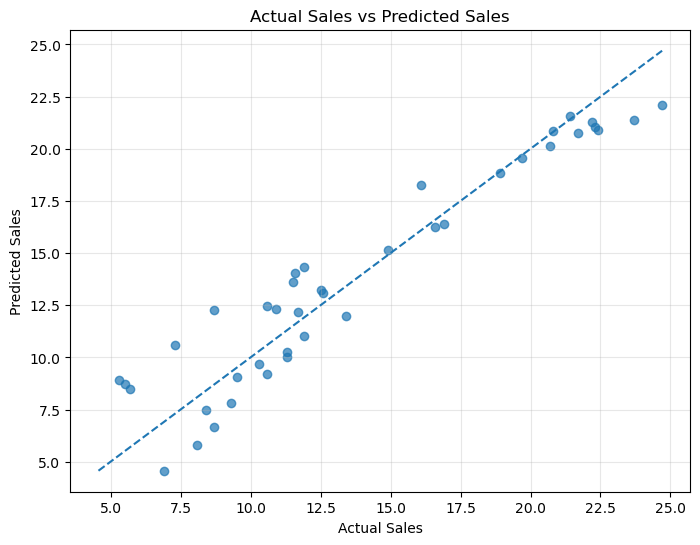

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Reference line representing perfect predictions
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")
plt.grid(True, alpha=0.3)
plt.show()

### Explanation
This scatter plot compares actual Sales with predicted Sales.

The diagonal reference line represents perfect predictions.

If points are close to the diagonal line, the predictions are close to the actual values.

If points are far away from the line, the model has larger prediction errors.

This visualization makes it easier to understand the model's prediction performance.

## Step 25 – Visualize the Regression Coefficients

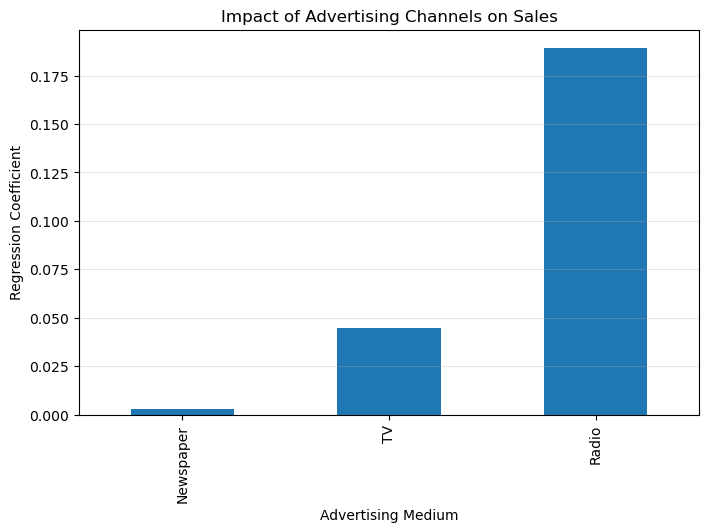

In [25]:
plt.figure(figsize=(8, 5))

coefficients.sort_values().plot(kind="bar")

plt.xlabel("Advertising Medium")
plt.ylabel("Regression Coefficient")
plt.title("Impact of Advertising Channels on Sales")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Explanation
This bar chart displays the learned coefficient for each advertising channel.

A larger positive coefficient indicates a stronger positive estimated relationship with Sales.

A coefficient close to zero indicates a weaker estimated relationship.

For this dataset, Radio generally has the strongest positive coefficient, while Newspaper is generally close to zero.

## Step 26 – Generate a Final Model Summary

In [26]:
print("FINAL MODEL SUMMARY")
print("=" * 50)

print(f"Intercept: {model.intercept_:.4f}")

print("\nCoefficients:")
for feature, coefficient in coefficients.items():
    print(f"  {feature}: {coefficient:.4f}")

print("\nEvaluation Metrics:")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")

print("\nNew Advertising Budget:")
print("  TV = 150")
print("  Radio = 20")
print("  Newspaper = 30")

print(f"\nPredicted Sales: {predicted_sales[0]:.4f}")

print("\nStrongest positive advertising coefficient:", strongest_medium)
print("Weakest coefficient by absolute magnitude:", weakest_medium)

FINAL MODEL SUMMARY
Intercept: 2.9791

Coefficients:
  TV: 0.0447
  Radio: 0.1892
  Newspaper: 0.0028

Evaluation Metrics:
  MAE:  1.4608
  MSE:  3.1741
  RMSE: 1.7816
  R²:   0.8994

New Advertising Budget:
  TV = 150
  Radio = 20
  Newspaper = 30

Predicted Sales: 13.5552

Strongest positive advertising coefficient: Radio
Weakest coefficient by absolute magnitude: Newspaper


### Explanation
This cell brings the important results together so they are easy to use in the final report or presentation.

It shows:

- Intercept
- Advertising coefficients
- MAE
- MSE
- RMSE
- R²
- Predicted Sales for the new budget
- Strongest advertising coefficient
- Weakest coefficient

# Step 27 – Business Recommendation

### Recommendation

Based on the regression coefficients, the company should **prioritize and optimize the advertising channel with the strongest positive estimated relationship with Sales**.

For the standard Advertising dataset, Radio typically has the strongest positive coefficient.

Therefore:

> **The company should consider increasing or optimizing its Radio advertising budget because Radio shows the strongest estimated positive relationship with Sales among the three channels.**

However, the company should not make budget decisions using coefficients alone. It should also consider the cost of each channel, customer reach, campaign quality, and return on investment (ROI).

---

# Step 28 – Technical Improvement

### Recommendation

The current model assumes a linear relationship between advertising expenditure and Sales.

Prediction accuracy could potentially be improved by:

- Testing Polynomial Regression for nonlinear relationships.
- Trying Random Forest or Gradient Boosting Regression.
- Using cross-validation.
- Performing feature engineering.
- Comparing multiple models using MAE, RMSE, and R².

### Recommended technical improvement

> **Use cross-validation to compare Multiple Linear Regression with nonlinear models such as Random Forest Regression and Polynomial Regression, then select the model that gives the best validation performance.**

---

# Step 29 – Final Conclusion

The project used **Multiple Linear Regression** to analyze the relationship between TV, Radio, Newspaper advertising expenditure, and Sales.

The model was trained on historical advertising data and evaluated on unseen test data.

The model was also used to predict Sales for the planned advertising budget:

- **TV = 150**
- **Radio = 20**
- **Newspaper = 30**

The regression coefficients were analyzed to understand the relative contribution of each advertising channel.

For the commonly used Advertising dataset, **Radio generally has the strongest positive coefficient**, while **Newspaper generally has the weakest coefficient**.

The model's quality should be reported using **MAE, MSE, RMSE, and R²**, using the exact values generated when the notebook is executed.

### Final project flow

**Load Data → Explore Data → Check Missing Values → Select Features → Train/Test Split → Build Linear Regression → Train Model → Predict → Evaluate → Predict New Budget → Analyze Coefficients → Visualize → Business Recommendation → Technical Improvement**
